In [1]:
import numpy as np
import openturns as ot
import openturns.viewer as otw

In [2]:
ot.RandomGenerator.SetSeed(0)

In [3]:
size = 10
inputObservations = ot.Sample([[0.5 + i] for i in range(size)])
inputObservations

class=Sample name=Unnamed implementation=class=SampleImplementation name=Unnamed size=10 dimension=1 data=[[0.5],[1.5],[2.5],[3.5],[4.5],[5.5],[6.5],[7.5],[8.5],[9.5]]

La fonction est :
$$
g(x) = a + b \exp(c x), 
$$
pour tout $x\in[0.5,9.5]$.

In [4]:
inVars = ["a", "b", "c", "x"]
formulas = ["a + b * exp(c * x)"]
g = ot.SymbolicFunction(inVars, formulas)
g

class=SymbolicFunction name=Unnamed implementation=class=FunctionImplementation name=Unnamed description=[a,b,c,x,y0] evaluationImplementation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,c,x] outputVariablesNames=[y0] formulas=[a + b * exp(c * x)] gradientImplementation=class=SymbolicGradient name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,c,x] outputVariablesNames=[y0] formulas=[a + b * exp(c * x)] hessianImplementation=class=SymbolicHessian name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,c,x] outputVariablesNames=[y0] formulas=[a + b * exp(c * x)]

In [5]:
p_ref = [2.8, 1.2, 0.5]
params = [0, 1, 2]
model = ot.ParametricFunction(g, params, p_ref)
model

class=FunctionImplementation name=Unnamed description=[x,y0] evaluationImplementation=class=ParametricEvaluation function=class=Function name=Unnamed implementation=class=FunctionImplementation name=Unnamed description=[a,b,c,x,y0] evaluationImplementation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,c,x] outputVariablesNames=[y0] formulas=[a + b * exp(c * x)] gradientImplementation=class=SymbolicGradient name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,c,x] outputVariablesNames=[y0] formulas=[a + b * exp(c * x)] hessianImplementation=class=SymbolicHessian name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,c,x] outputVariablesNames=[y0] formulas=[a + b * exp(c * x)] parameters positions=[0,1,2] parameters=class=PointWithDescription name=Unnamed dimension=3 description=[a,b,c] values=[2.8,1.2,0.5] input positions=[3] gradientImplementation=class=ParametricGradient evaluation=class=ParametricEvaluation function=class=Function name=Unnamed implementation=class=FunctionImplementation name=Unnamed description=[a,b,c,x,y0] evaluationImplementation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,c,x] outputVariablesNames=[y0] formulas=[a + b * exp(c * x)] gradientImplementation=class=SymbolicGradient name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,c,x] outputVariablesNames=[y0] formulas=[a + b * exp(c * x)] hessianImplementation=class=SymbolicHessian name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,c,x] outputVariablesNames=[y0] formulas=[a + b * exp(c * x)] parameters positions=[0,1,2] parameters=class=PointWithDescription name=Unnamed dimension=3 description=[a,b,c] values=[2.8,1.2,0.5] input positions=[3] hessianImplementation=class=ParametricHessian evaluation=class=ParametricEvaluation function=class=Function name=Unnamed implementation=class=FunctionImplementation name=Unnamed description=[a,b,c,x,y0] evaluationImplementation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,c,x] outputVariablesNames=[y0] formulas=[a + b * exp(c * x)] gradientImplementation=class=SymbolicGradient name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,c,x] outputVariablesNames=[y0] formulas=[a + b * exp(c * x)] hessianImplementation=class=SymbolicHessian name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,c,x] outputVariablesNames=[y0] formulas=[a + b * exp(c * x)] parameters positions=[0,1,2] parameters=class=PointWithDescription name=Unnamed dimension=3 description=[a,b,c] values=[2.8,1.2,0.5] input positions=[3]

In [6]:
sigmaNoiseObservation = 5.0
observationOutputNoise = ot.Normal([0.0], [sigmaNoiseObservation], ot.IdentityMatrix(1))
observationOutputNoise

class=Normal name=Normal dimension=1 mean=class=Point name=Unnamed dimension=1 values=[0] sigma=class=Point name=Unnamed dimension=1 values=[5] correlationMatrix=class=CorrelationMatrix dimension=1 implementation=class=MatrixImplementation name=Unnamed rows=1 columns=1 values=[1]

In [7]:
outputObservations = model(inputObservations)
outputObservations += observationOutputNoise.getSample(size)
outputObservations

class=Sample name=Unnamed implementation=class=SampleImplementation name=Unnamed size=10 dimension=1 description=[y0] data=[[7.38184],[-0.990465],[4.79708],[15.7329],[3.27836],[23.3214],[31.9734],[61.0115],[90.9798],[145.467]]

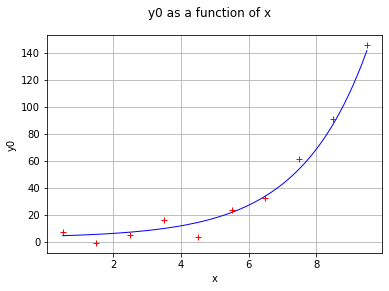

In [8]:
graph = model.draw(0.5, 9.5)
cloud = ot.Cloud(inputObservations[:, 0], outputObservations)
cloud.setColor("red")
graph.add(cloud)
otw.View(graph).save("exp_observations.pdf")

In [9]:
candidate = ot.Point([1.0] * 3)
candidate

class=Point name=Unnamed dimension=3 values=[1,1,1]

In [10]:
p = candidate.getSize()
parameterCovariance = ot.CovarianceMatrix(p)
for i in range(p):
    parameterCovariance[i, i] = 3.0 + (1.0 + i) * (1.0 + i)
    for j in range(i):
        parameterCovariance[i, j] = 1.0 / (1.0 + i + j)
parameterCovariance

class=CovarianceMatrix dimension=3 implementation=class=MatrixImplementation name=Unnamed rows=3 columns=3 values=[4,0.5,0.333333,0.5,7,0.25,0.333333,0.25,12]

In [11]:
np.linalg.cond(parameterCovariance)

3.077522667965874

In [12]:
s = parameterCovariance.computeSingularValues()
print(s)
max(s) / min(s)

[12.0285,7.06299,3.9085]


3.077522667965874

In [13]:
errorCovariance = ot.CovarianceMatrix([[3.0]])
errorCovariance

class=CovarianceMatrix dimension=1 implementation=class=MatrixImplementation name=Unnamed rows=1 columns=1 values=[3]

In [14]:
np.linalg.cond(errorCovariance)

1.0

In [15]:
s = errorCovariance.computeSingularValues()
s

class=Point name=Unnamed dimension=1 values=[3]

In [16]:
algo = ot.GaussianLinearCalibration(
    model,
    inputObservations,
    outputObservations,
    candidate,
    parameterCovariance,
    errorCovariance,
    "SVD",
)
algo.run()
calibrationResult = algo.getResult()

## Analysis of the results

The `getParameterMAP` method returns the maximum of the posterior distribution of $\theta$.

In [17]:
thetaStar = calibrationResult.getParameterMAP()
thetaStar

class=Point name=Unnamed dimension=3 values=[5.80159,0.0895724,0.991661]

In [18]:
thetaPosterior = calibrationResult.getParameterPosterior()

In [19]:
# See Ticket 1106 on github
ot.ResourceMap.SetAsUnsignedInteger("Normal-SmallDimension", 1)
thetaPosterior.computeBilateralConfidenceIntervalWithMarginalProbability(0.95)[0]

class=Interval name=Unnamed dimension=3 lower bound=class=Point name=Unnamed dimension=3 values=[4.28424,0.0826885,0.990933] upper bound=class=Point name=Unnamed dimension=3 values=[7.31895,0.0964563,0.992389] finite lower bound=[1,1,1] finite upper bound=[1,1,1]

In [20]:
covarianceThetaStar = thetaPosterior.getCovariance()
covarianceThetaStar

class=CovarianceMatrix dimension=3 implementation=class=MatrixImplementation name=Unnamed rows=3 columns=3 values=[0.466151,-0.00109466,0.00011205,-0.00109466,9.59446e-06,-1.01331e-06,0.00011205,-1.01331e-06,1.07223e-07]

## Calculs génériques

In [21]:
parameterDimension = candidate.getDimension()

In [22]:
model.setParameter(candidate)
modelObservations = model(inputObservations)
modelObservations[0:5]

class=Sample name=Unnamed implementation=class=SampleImplementation name=Unnamed size=5 dimension=1 description=[y0] data=[[2.64872],[5.48169],[13.1825],[34.1155],[91.0171]]

In [23]:
outputDimension = modelObservations.getDimension()
outputDimension

1

In [24]:
transposedGradientObservations = ot.Matrix(parameterDimension, size * outputDimension)
for i in range(size):
    g = model.parameterGradient(inputObservations[i])
    for j in range(outputDimension):
        for k in range(parameterDimension):
            transposedGradientObservations[k, i * outputDimension + j] = g[k, j]
transposedGradientObservations

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=3 columns=10 values=[1,1.64872,0.824361,1,4.48169,6.72253,1,12.1825,30.4562,1,33.1155,115.904,1,90.0171,405.077,1,244.692,1345.81,1,665.142,4323.42,1,1808.04,13560.3,1,4914.77,41775.5,1,13359.7,126917]

In [25]:
gradientObservations = transposedGradientObservations.transpose()
gradientObservations

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=10 columns=3 values=[1,1,1,1,1,1,1,1,1,1,1.64872,4.48169,12.1825,33.1155,90.0171,244.692,665.142,1808.04,4914.77,13359.7,0.824361,6.72253,30.4562,115.904,405.077,1345.81,4323.42,13560.3,41775.5,126917]

In [26]:
residuals = outputObservations - modelObservations
# Stack the residuals by observation,
#   deltay = [residuals[i,0],residuals[i,1],...,residuals[i,outputDimension]]
deltay = ot.Point(size * outputDimension)
for i in range(size):
    for j in range(outputDimension):
        deltay[i * outputDimension + j] = residuals[i, j]
deltay

class=Point name=Unnamed dimension=10 values=[4.73312,-6.47215,-8.38541,-18.3825,-87.7388,-222.371,-634.168,-1748.03,-4824.79,-13215.3]

In [27]:
observationDimension = errorCovariance.getDimension()
observationDimension

1

In [28]:
R = ot.CovarianceMatrix(deltay.getSize())
for i in range(size):
    for j in range(observationDimension):
        for k in range(observationDimension):
            R[
                i * observationDimension + j, i * observationDimension + k
            ] = errorCovariance[j, k]
R[0:10, :]

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=10 columns=10 values=[3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3]

## Par résolution d'un problème de moindres carrés linéaires

Calcule le facteur de Cholesky $L_B$ de $B$ tel que : 
$$
B = L_B L_B^T
$$
où $L_B$ est une matrice triangulaire inférieure.

In [29]:
B = ot.CovarianceMatrix(parameterCovariance)
LB = B.computeCholesky()
LB

class=TriangularMatrix dimension=3 implementation=class=MatrixImplementation name=Unnamed rows=3 columns=3 values=[2,0.25,0.166667,0,2.63391,0.0790965,0,0,3.45919]

Calcule le facteur de Cholesky $L_R$ de $R$ tel que : 
$$
R = L_R L_R^T
$$
où $L_R$ est une matrice triangulaire inférieure.

In [30]:
LR = R.computeCholesky()
LR[0:5, :]

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=5 columns=10 values=[1.73205,0,0,0,0,0,1.73205,0,0,0,0,0,1.73205,0,0,0,0,0,1.73205,0,0,0,0,0,1.73205,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]

Calcule $L_B^{-1}$, première partie de la matrice de conception étendue.

In [31]:
ILB = ot.IdentityMatrix(parameterDimension)
invLB = LB.solveLinearSystem(ILB)
invLB

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=3 columns=3 values=[0.5,-0.0474579,-0.0230053,0,0.379663,-0.00868124,0,0,0.289085]

Calcule $L_R^{-1}J$, seconde partie de la matrice de conception étendue.

In [32]:
invLRJ = LR.solveLinearSystem(gradientObservations)
invLRJ

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=10 columns=3 values=[0.57735,0.57735,0.57735,0.57735,0.57735,0.57735,0.57735,0.57735,0.57735,0.57735,0.95189,2.5875,7.03357,19.1192,51.9714,141.273,384.02,1043.87,2837.54,7713.24,0.475945,3.88126,17.5839,66.9173,233.871,777.001,2496.13,7829.05,24119.1,73275.8]

Crée $\bar{A}$, la matrice de conception étendue du problème de moindres carrés linéaires.

In [33]:
Abar = ot.Matrix(parameterDimension + size * outputDimension, parameterDimension)
Abar[0:parameterDimension, 0:parameterDimension] = invLB
for i in range(size):
    for j in range(outputDimension):
        for k in range(parameterDimension):
            Abar[i * outputDimension + j + parameterDimension, k] = -invLRJ[
                i * outputDimension + j, k
            ]
Abar

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=13 columns=3 values=[0.5,-0.0474579,-0.0230053,-0.57735,-0.57735,-0.57735,-0.57735,-0.57735,-0.57735,-0.57735,-0.57735,-0.57735,-0.57735,0,0.379663,-0.00868124,-0.95189,-2.5875,-7.03357,-19.1192,-51.9714,-141.273,-384.02,-1043.87,-2837.54,-7713.24,0,0,0.289085,-0.475945,-3.88126,-17.5839,-66.9173,-233.871,-777.001,-2496.13,-7829.05,-24119.1,-73275.8]

In [34]:
np.linalg.cond(Abar)

53272.01247584681

Calcule $L_R^{-1} (y - H(\mu))$, second membre du résidu étendu.

In [35]:
invLRz = LR.solveLinearSystem(deltay)
invLRz

class=Point name=Unnamed dimension=10 values=[2.73267,-3.7367,-4.84132,-10.6132,-50.656,-128.386,-366.137,-1009.23,-2785.59,-7629.83]

Créée $\bar{y}$ le second membre du problème de moindres carrés linéaires étendu.

In [36]:
ybar = ot.Point(parameterDimension + size * outputDimension)
for i in range(size):
    for j in range(outputDimension):
        ybar[i * outputDimension + j + parameterDimension] = -invLRz[
            i * outputDimension + j
        ]
ybar

class=Point name=Unnamed dimension=13 values=[0,0,0,-2.73267,3.7367,4.84132,10.6132,50.656,128.386,366.137,1009.23,2785.59,7629.83]

In [37]:
method = ot.SVDMethod(Abar)
method

class=SVDMethod

In [38]:
deltaTheta = method.solve(ybar)
deltaTheta

class=Point name=Unnamed dimension=3 values=[4.80159,-0.910428,-0.00833907]

In [39]:
thetaStarLLSQ = candidate + deltaTheta
thetaStarLLSQ

class=Point name=Unnamed dimension=3 values=[5.80159,0.0895724,0.991661]

In [40]:
covarianceThetaLLSQ = method.getGramInverse()
covarianceThetaLLSQ

class=CovarianceMatrix dimension=3 implementation=class=MatrixImplementation name=Unnamed rows=3 columns=3 values=[0.466151,-0.00109466,0.00011205,-0.00109466,9.59446e-06,-1.01331e-06,0.00011205,-1.01331e-06,1.07223e-07]

## Calibration based on Kalman matrix

Compute inverses of B and R.

In [41]:
B = ot.CovarianceMatrix(parameterCovariance)
IB = ot.IdentityMatrix(parameterDimension)
invB = B.solveLinearSystem(IB)

In [42]:
IR = ot.IdentityMatrix(R.getNbRows())
invR = R.solveLinearSystem(IR)

Calcule $A^{-1} = B^{-1} + J^T R^{-1} J = B^{-1} + J^T (J^T R^{-1})^T$.

Soit $C =J^T R^{-1}$. 

Cela implique $A^{-1} = B^{-1} + J^T C^T$.

In [43]:
C = gradientObservations.transpose() * invR

In [44]:
invA = invB + C * gradientObservations
invA

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=3 columns=3 values=[3.58611,7044.59,62827.1,7044.59,6.8806e+07,6.42887e+08,62827.1,6.42887e+08,6.01926e+09]

Calcule $K = A J^T R^{-1}$ en tant que solution de l'équation matricielle $A^{-1}K = C$.

In [45]:
K = invA.solveLinearSystem(C)
K

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=3 columns=10 values=[8.6877e-09,3.6595e-06,-3.90808e-07,2.09324e-08,8.81733e-06,-9.41363e-07,4.96452e-08,2.09121e-05,-2.23183e-06,1.15268e-07,4.85546e-05,-5.17946e-06,2.59869e-07,0.000109466,-1.16691e-05,5.61111e-07,0.000236363,-2.51702e-05,1.13037e-06,0.000476167,-5.06176e-05,1.99929e-06,0.000842231,-8.92036e-05,2.51693e-06,0.00106043,-0.000110946,-1.08937e-06,-0.000458161,5.59623e-05]

In [46]:
np.linalg.cond(K)

5.748910294872463e+18

Calcule $\hat{\theta} = \mu  + K (y - H(\mu ))$.

In [47]:
thetaStarKalman = candidate + K * deltay
thetaStarKalman

class=Point name=Unnamed dimension=3 values=[0.997891,0.100853,0.990506]

In [48]:
L = IB - K * gradientObservations

In [49]:
covarianceThetaStarKalman = K * R * K.transpose() + L * B * L.transpose()
covarianceThetaStarKalman

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=3 columns=3 values=[3.99781,-0.0093882,0.000960979,-0.0093882,2.90705e-05,-3.00688e-06,0.000960979,-3.00688e-06,3.11286e-07]

In [50]:
np.linalg.cond(covarianceThetaStarKalman)

24338490972.627

## Vérification de la fonction cout

L'objectif est de vérifier laquelle des deux solutions minimise la fonction cout.

In [51]:
def squaredMahalanobis(x, y, covariance):
    """Squared Mahalanobis distance"""
    delta = x - y
    z = covariance.solveLinearSystem(delta)
    m = delta.dot(z)
    return m


def costFunction(
    theta,
    candidate,
    parameterCovariance,
    modelObservations,
    gradientObservations,
    outputObservations,
    errorCovariance,
):
    """Cost function for linear gaussian calibration"""
    # 1. Background part of the cost function
    Jb = 0.5 * squaredMahalanobis(candidate, theta, parameterCovariance)
    # 2. Observation part of the cost function
    deltaTheta = theta - candidate
    # Observation values of the model
    YfunPoint = ot.Point(np.array(modelObservations).flatten())
    # Predicted values of the model based on linearization
    Ypredictions = YfunPoint + gradientObservations * deltaTheta
    YobsPoint = ot.Point(np.array(outputObservations).flatten())
    Jo = 0.5 * squaredMahalanobis(YobsPoint, Ypredictions, errorCovariance)
    # 3. Sum of the two parts
    J = Jb + Jo
    return [J, Jb, Jo]

Avant calage.

In [52]:
costFunction(
    candidate,
    candidate,
    parameterCovariance,
    modelObservations,
    gradientObservations,
    outputObservations,
    R,
)

[33572847.329353295, 0.0, 33572847.329353295]

Calage par la matrice de Kalman.

In [53]:
thetaStarKalman

class=Point name=Unnamed dimension=3 values=[0.997891,0.100853,0.990506]

In [54]:
costFunction(
    thetaStarKalman,
    candidate,
    parameterCovariance,
    modelObservations,
    gradientObservations,
    outputObservations,
    R,
)

[79.73183186193263, 0.058247196887854166, 79.67358466504479]

Calage par décomposition de Cholesky.

In [55]:
thetaStarLLSQ

class=Point name=Unnamed dimension=3 values=[5.80159,0.0895724,0.991661]

In [56]:
costFunction(
    thetaStarLLSQ,
    candidate,
    parameterCovariance,
    modelObservations,
    gradientObservations,
    outputObservations,
    R,
)

[54.980636651446616, 3.0518913894548727, 51.92874526199174]

## Validation

In [57]:
def GaussianLinearCalibrationCompute(
    model,
    inputObservations,
    outputObservations,
    candidate,
    parameterCovariance,
    errorCovariance,
):
    """Use GaussianLinearCalibration"""
    algo = ot.GaussianLinearCalibration(
        model,
        inputObservations,
        outputObservations,
        candidate,
        parameterCovariance,
        errorCovariance,
    )
    algo.run()
    calibrationResult = algo.getResult()
    thetaStar = calibrationResult.getParameterMAP()
    thetaPosterior = calibrationResult.getParameterPosterior()
    covarianceThetaStar = thetaPosterior.getCovariance()
    return thetaStar, covarianceThetaStar

## Calibration based on Kalman matrix

In [58]:
def ComputeFromKalman(
    model,
    inputObservations,
    outputObservations,
    candidate,
    parameterCovariance,
    errorCovariance,
):
    """Compute the solution from the Kalman matrix"""
    parameterDimension = candidate.getDimension()
    size = inputObservations.getSize()
    # Compute model observations
    model.setParameter(candidate)
    modelObservations = model(inputObservations)
    # Compute residuals
    residuals = outputObservations - modelObservations
    outputDimension = modelObservations.getDimension()
    # Stack the residuals by observation,
    #   deltay = [residuals[i,0],residuals[i,1],...,residuals[i,outputDimension]]
    deltay = ot.Point(size * outputDimension)
    for i in range(size):
        for j in range(outputDimension):
            deltay[i * outputDimension + j] = residuals[i, j]
    # Compute J
    transposedGradientObservations = ot.Matrix(
        parameterDimension, size * outputDimension
    )
    for i in range(size):
        g = model.parameterGradient(inputObservations[i])
        for j in range(outputDimension):
            for k in range(parameterDimension):
                transposedGradientObservations[k, i * outputDimension + j] = g[k, j]
    gradientObservations = transposedGradientObservations.transpose()
    print("Cond(Gradient)=", np.linalg.cond(gradientObservations))
    # Compute R
    observationDimension = errorCovariance.getDimension()
    R = ot.CovarianceMatrix(deltay.getSize())
    for i in range(size):
        for j in range(observationDimension):
            for k in range(observationDimension):
                R[
                    i * observationDimension + j, i * observationDimension + k
                ] = errorCovariance[j, k]
    # Compute B, inverse of B
    B = ot.CovarianceMatrix(parameterCovariance)
    IB = ot.IdentityMatrix(parameterDimension)
    invB = B.solveLinearSystem(IB)
    # Compute inverse of R
    IR = ot.IdentityMatrix(R.getNbRows())
    invR = R.solveLinearSystem(IR)
    #
    C = gradientObservations.transpose() * invR
    invA = invB + C * gradientObservations
    K = invA.solveLinearSystem(C)
    print("Cond(Kalman)=", np.linalg.cond(K))
    thetaStar = candidate + K * deltay
    #
    L = IB - K * gradientObservations
    covarianceThetaStar = K * R * K.transpose() + L * B * L.transpose()
    return thetaStar, covarianceThetaStar

In [59]:
def ComputeFromLinearLeastSquaresCholesky(
    model,
    inputObservations,
    outputObservations,
    candidate,
    parameterCovariance,
    errorCovariance,
):
    parameterDimension = candidate.getDimension()
    size = inputObservations.getSize()
    # Compute model observations
    model.setParameter(candidate)
    modelObservations = model(inputObservations)
    # Compute residuals
    residuals = outputObservations - modelObservations
    outputDimension = modelObservations.getDimension()
    # Stack the residuals by observation,
    #   deltay = [residuals[i,0],residuals[i,1],...,residuals[i,outputDimension]]
    deltay = ot.Point(size * outputDimension)
    for i in range(size):
        for j in range(outputDimension):
            deltay[i * outputDimension + j] = residuals[i, j]
    # Compute J
    transposedGradientObservations = ot.Matrix(
        parameterDimension, size * outputDimension
    )
    for i in range(size):
        g = model.parameterGradient(inputObservations[i])
        for j in range(outputDimension):
            for k in range(parameterDimension):
                transposedGradientObservations[k, i * outputDimension + j] = g[k, j]
    gradientObservations = transposedGradientObservations.transpose()
    # Compute R
    observationDimension = errorCovariance.getDimension()
    R = ot.CovarianceMatrix(deltay.getSize())
    for i in range(size):
        for j in range(observationDimension):
            for k in range(observationDimension):
                R[
                    i * observationDimension + j, i * observationDimension + k
                ] = errorCovariance[j, k]
    # Create B, R, inv(B), inv(R)
    B = ot.CovarianceMatrix(parameterCovariance)
    LB = B.computeCholesky()
    LR = R.computeCholesky()
    #
    ILB = ot.IdentityMatrix(parameterDimension)
    invLB = LB.solveLinearSystem(ILB)
    invLRJ = LR.solveLinearSystem(gradientObservations)
    # Compute Abar
    Abar = ot.Matrix(parameterDimension + size * outputDimension, parameterDimension)
    Abar[0:parameterDimension, 0:parameterDimension] = invLB
    for i in range(size):
        for j in range(outputDimension):
            for k in range(parameterDimension):
                Abar[i * outputDimension + j + parameterDimension, k] = -invLRJ[
                    i * outputDimension + j, k
                ]
    #
    invLRz = LR.solveLinearSystem(deltay)
    # Compute ybar
    ybar = ot.Point(parameterDimension + size * outputDimension)
    for i in range(size):
        for j in range(outputDimension):
            ybar[i * outputDimension + j + parameterDimension] = -invLRz[
                i * outputDimension + j
            ]
    # Solve the least squares problem
    print("Cond(Linear Least Squares/Cholesky)=", np.linalg.cond(Abar))
    method = ot.SVDMethod(Abar)
    deltaTheta = method.solve(ybar)
    thetaStar = deltaTheta + candidate
    covarianceThetaStar = method.getGramInverse()
    return thetaStar, covarianceThetaStar

## GaussianLinearCalibrationCompute

In [60]:
thetaStar, covarianceThetaStar = GaussianLinearCalibrationCompute(
    model,
    inputObservations,
    outputObservations,
    candidate,
    parameterCovariance,
    errorCovariance,
)

In [61]:
thetaStar

class=Point name=Unnamed dimension=3 values=[5.80159,0.0895724,0.991661]

In [62]:
covarianceThetaStar

class=CovarianceMatrix dimension=3 implementation=class=MatrixImplementation name=Unnamed rows=3 columns=3 values=[0.466151,-0.00109466,0.00011205,-0.00109466,9.59446e-06,-1.01331e-06,0.00011205,-1.01331e-06,1.07223e-07]

## Kalman

In [63]:
thetaStar, covarianceThetaStar = ComputeFromKalman(
    model,
    inputObservations,
    outputObservations,
    candidate,
    parameterCovariance,
    errorCovariance,
)
thetaStar

Cond(Gradient)= 56719.62347724023
Cond(Kalman)= 5.748910294872463e+18


class=Point name=Unnamed dimension=3 values=[0.997891,0.100853,0.990506]

In [64]:
covarianceThetaStar

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=3 columns=3 values=[3.99781,-0.0093882,0.000960979,-0.0093882,2.90705e-05,-3.00688e-06,0.000960979,-3.00688e-06,3.11286e-07]

## From the extended linear least squares

In [65]:
thetaStar, covarianceThetaStar = ComputeFromLinearLeastSquaresCholesky(
    model,
    inputObservations,
    outputObservations,
    candidate,
    parameterCovariance,
    errorCovariance,
)
thetaStar

Cond(Linear Least Squares/Cholesky)= 53272.01247584681


class=Point name=Unnamed dimension=3 values=[5.80159,0.0895724,0.991661]

In [66]:
covarianceThetaStar

class=CovarianceMatrix dimension=3 implementation=class=MatrixImplementation name=Unnamed rows=3 columns=3 values=[0.466151,-0.00109466,0.00011205,-0.00109466,9.59446e-06,-1.01331e-06,0.00011205,-1.01331e-06,1.07223e-07]